# Power spectrum of radio visibilities

This notebook goes through how to make a (delay) power spectrum from mock HERA radio visibilities.


https://arxiv.org/pdf/2108.02263.

We will use the BayesLIM (https://bayeslim.readthedocs.io/en/latest/#) codebase for this simply for its utility functions: nothing in this notebook will touch Bayesian analysis.

June 24, 2026

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import torch

import bayeslim as ba
from pyuvdata import UVData

In [5]:
torch.set_default_dtype(torch.float64)

In [6]:
cosmo = ba.cosmology.Cosmology()

# 1. Load and prepare the data

Load the data with pyuvdata.

In [96]:
# just load metadata
uvd = UVData()
uvd.read("../zen.h6c_idr2_validation.sum.uvh5", read_data=False)

uvd.conjugate_bls()

# get antenna positions
antpos = uvd.telescope.get_enu_antpos()
antpos[:, 2] = 0  # flatten z axis
ants = uvd.telescope.antenna_numbers
antpos_d = dict(zip(ants.tolist(), antpos))

# get other metadata
freqs = torch.as_tensor(uvd.freq_array)
lsts = np.unique(np.unwrap(uvd.lst_array))
times_sec = torch.as_tensor(np.unique(uvd.time_array))
times_sec -= times_sec.min()
avg_redshift = cosmo.f2z(uvd.freq_array.mean())

print(f"Local sidereal time (LST) {lsts[0]*12/np.pi:.1f} - {lsts[-1]*12/np.pi:.1f} hours | Ntimes = {len(lsts)}")
print(f"Frequency band {freqs[0]/1e6:.1f} - {freqs[-1]/1e6:.1f} | Nfreqs = {len(freqs)}")

Local sidereal time (LST) 0.3 - 4.7 hours | Ntimes = 1600
Frequency band 120.2 - 193.3 | Nfreqs = 600


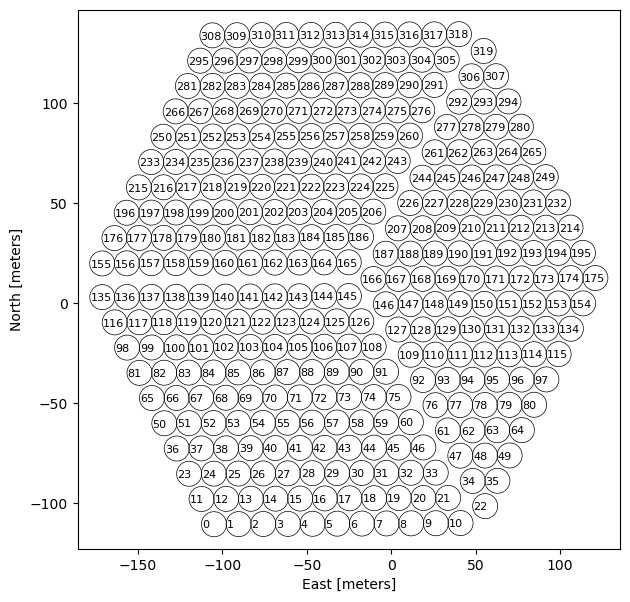

In [8]:
# plot antenna layout
plt.figure(figsize=(7,7))
plt.scatter(*antpos[:, :2].T, fc='none', ec='k', s=325, lw=.5)
for i, a in enumerate(ants):
    plt.text(antpos[i,0]-7, antpos[i,1]-2, a, fontsize=8)
plt.xlabel('East [meters]'); plt.ylabel('North [meters]');

In [9]:
# get all baselines shorter than 80 meters
bl_vecs = np.vstack([antpos_d[bl[1]] - antpos_d[bl[0]] for bl in uvd.get_antpairs()])
all_bls = [bl for i, bl in enumerate(uvd.get_antpairs()) if np.linalg.norm(bl_vecs[i]) < 80]

In [88]:
# now load the data: load only 1 polarization
uvd.read("../zen.h6c_idr2_validation.sum.uvh5", bls=all_bls, polarizations=['ee'])
uvd.conjugate_bls()

# now load the eor-only data: load only 1 polarization
uve = UVData()
uve.read("../zen.h6c_idr2_validation.eor.uvh5", bls=all_bls, polarizations=['ee'])
uve.conjugate_bls()

In [90]:
# re-sort the data into (Nbls, Ntimes, Nfreqs), exclude auto-correlation (bl[0] == bl[1])
bls = [bl for bl in all_bls if bl[0] != bl[1]]
data = torch.as_tensor(np.array([uvd.get_data(bl) for bl in bls]))
flags = torch.as_tensor(np.array([uvd.get_flags(bl) for bl in bls]))

eor = torch.as_tensor(np.array([uve.get_data(bl) for bl in bls]))

In [52]:
# get noise variance from autocorr
auto_bl = all_bls[0]
assert auto_bl[0] == auto_bl[1]
noise = uvd.get_data(auto_bl).real**2 / (uvd.integration_time.mean() * uvd.channel_width.mean())

# multiply noise by an arbitrary factor for testing
noise *= .1

# set flagged noise pixels to a large value
noise = torch.as_tensor(noise[None, :, :]) + flags * 1e6

In [ ]:
# free the UVData from RAM if possible
del uvd, uve

In [97]:
# setup telescope model
hera_telescope = ba.telescope_model.TelescopeModel(
    (uvd.telescope.location.lon.deg, uvd.telescope.location.lat.deg, uvd.telescope.location.height)
)

# setup a VisData object from BayesLIM
# data must be shape (1, 1, Nbls, Ntimes, Nfreqs)
vd = ba.VisData()
vd.setup_meta(telescope=hera_telescope, antpos=dict(zip(ants.tolist(), torch.as_tensor(antpos))))
vd.setup_data(bls, np.unique(uvd.time_array), uvd.freq_array, 'ee', 
              data=data[None, None], flags=flags[None, None], icov=1/noise[None, None])

# setup a VisData object from BayesLIM
# data must be shape (1, 1, Nbls, Ntimes, Nfreqs)
ve = ba.VisData()
ve.setup_meta(telescope=hera_telescope, antpos=dict(zip(ants.tolist(), torch.as_tensor(antpos))))
ve.setup_data(bls, np.unique(uvd.time_array), uvd.freq_array, 'ee', 
              data=eor[None, None], flags=flags[None, None], icov=1/noise[None, None])

In [100]:
# get redundant info
redtol = 1.0  # redundant baseline tolerance in meters
reds, red_vecs, bl2red = ba.telescope_model.build_reds(vd.antpos, bls=vd.bls, redtol=redtol)[:3]
red_vecs = torch.stack(red_vecs)
red_lens = red_vecs.norm(dim=-1)

# resort bls to increasing length
vd.select(bl=ba.utils.flatten(reds), inplace=True)
ve.select(bl=ba.utils.flatten(reds), inplace=True)

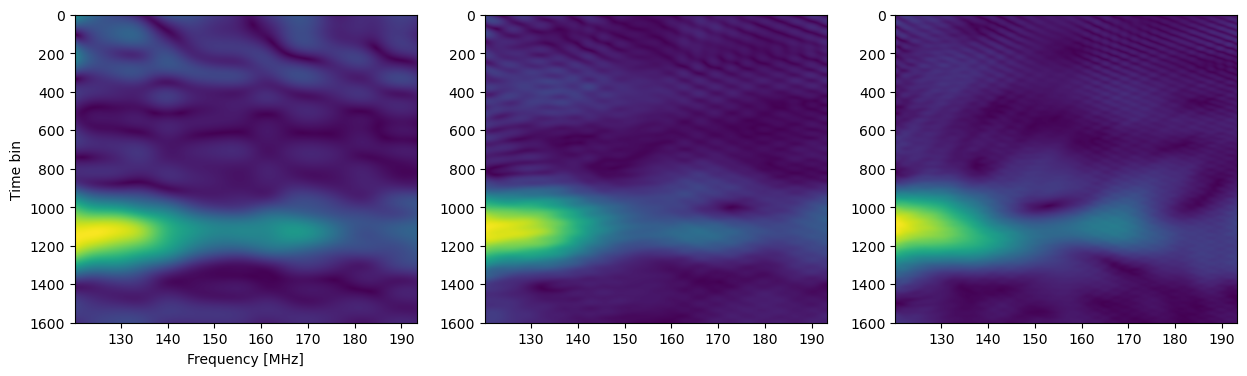

In [101]:
# plot three different baselines in time, freq space
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(vd[(0, 1)].abs(), aspect='auto', extent=[vd.freqs[0]/1e6, vd.freqs[-1]/1e6, vd.Ntimes, 0]);
axes[1].imshow(vd[(0, 3)].abs(), aspect='auto', extent=[vd.freqs[0]/1e6, vd.freqs[-1]/1e6, vd.Ntimes, 0]);
axes[2].imshow(vd[(0, 5)].abs(), aspect='auto', extent=[vd.freqs[0]/1e6, vd.freqs[-1]/1e6, vd.Ntimes, 0]);
axes[0].set_xlabel('Frequency [MHz]'); axes[0].set_ylabel('Time bin');

In [102]:
# define Fourier Transform operations
FT1 = ba.fft.FFT(dim=-1, abs=False, N=vd.Nfreqs, ndim=2, window='bh', dx=np.diff(vd.freqs)[0]/1e9) # delay
FT2 = ba.fft.FFT(dim=-2, abs=False, N=vd.Ntimes, ndim=2, window='bh', dx=np.diff(times_sec)[0]*1e3) # fringe rate

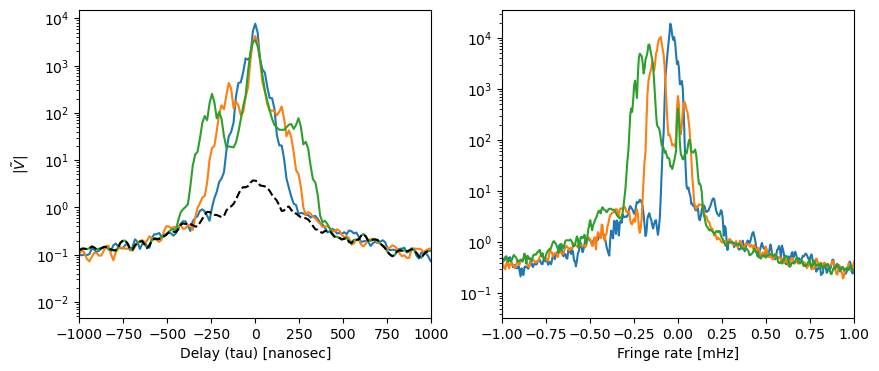

In [107]:
# plot the delay transform (FT-frequency) and fringe-rate transform (FT-time) (1D fourier space)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(FT1.freqs, FT1(vd[(0, 1)]).abs().mean(0))
axes[0].plot(FT1.freqs, FT1(vd[(0, 3)]).abs().mean(0))
axes[0].plot(FT1.freqs, FT1(vd[(0, 5)]).abs().mean(0))
axes[0].plot(FT1.freqs, FT1(ve[(0, 5)]).abs().mean(0), c='k', ls='--')
axes[0].set_yscale('log'); axes[0].set_xlim(-1000, 1000)
axes[0].set_xlabel('Delay (tau) [nanosec]'); axes[0].set_ylabel(r'$|\tilde{V}|$');

axes[1].plot(FT2.freqs, FT2(vd[(0, 1)]).abs().mean(1))
axes[1].plot(FT2.freqs, FT2(vd[(0, 3)]).abs().mean(1))
axes[1].plot(FT2.freqs, FT2(vd[(0, 5)]).abs().mean(1))
axes[1].set_yscale('log'); axes[1].set_xlim(-1, 1)
axes[1].set_xlabel('Fringe rate [mHz]'); axes[0].set_ylabel(r'$|\tilde{V}|$');

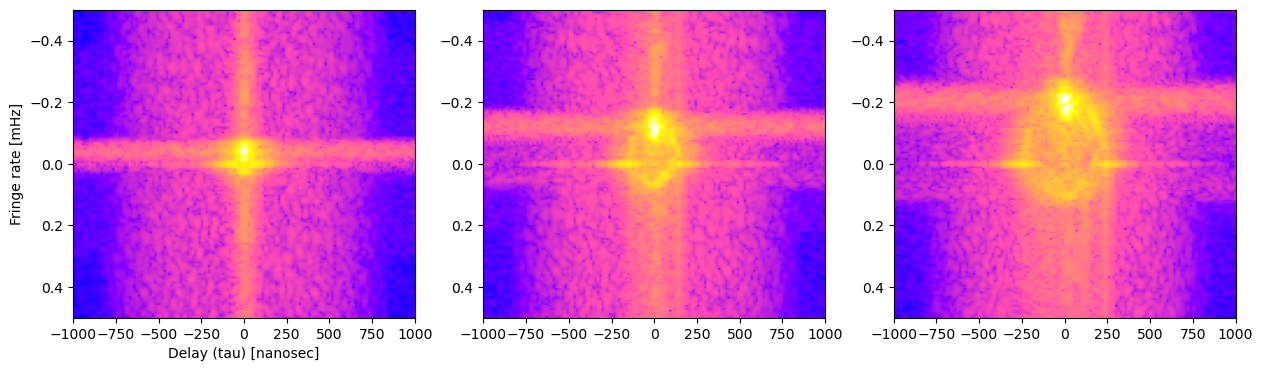

In [108]:
# plot delay + fringe-rate transform (2D fourier space)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(FT1(FT2(vd[(0, 1)])).abs().log(), aspect='auto', cmap='gnuplot2',
               extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]]);
axes[0].set_xlim(-1000, 1000); axes[0].set_ylim(.5, -.5)
axes[1].imshow(FT1(FT2(vd[(0, 3)])).abs().log(), aspect='auto', cmap='gnuplot2',
               extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]]);
axes[1].set_xlim(-1000, 1000); axes[1].set_ylim(.5, -.5)
axes[2].imshow(FT1(FT2(vd[(0, 5)])).abs().log(), aspect='auto', cmap='gnuplot2',
               extent=[FT1.freqs[0], FT1.freqs[-1], FT2.freqs[-1], FT2.freqs[0]]);
axes[2].set_xlim(-1000, 1000); axes[2].set_ylim(.5, -.5)
axes[0].set_xlabel('Delay (tau) [nanosec]'); axes[0].set_ylabel('Fringe rate [mHz]');

# Take a coherent redundant baseline average

The visibilities are complex, with an amplitude and a phase. A *coherent* average means we are averaging the *complex-valued* visibilities. This means that the phase of the data we are averaging must be aligned, otherwise the signal will *decohere*. We are allowed to take coherent average across two different axes: redundant visibilities (visibilities that share the same baseline vector), which measure the same cosmological signal, and nearby time integrations, which see *mostly* the same sky patch, and thus measure *mostly* the same visibility.

If we have full baseline data then we can coherently average the data within a redundant set. This is given to us by our previously computed reds list.

In [109]:
# redundantly average the data
vd_ravg = vd.bl_average(reds=reds, inplace=False)
ve_ravg = ve.bl_average(reds=reds, inplace=False)

assert vd_ravg.Nbls == len(reds)

# Take a coherent time average

If we average data that is too far separated in time, then the phases will be offset and the signal will decohere.

To take a coherent time average, we first choose a time window. For HERA, a reasonable coherent time average window is ~5 minutes (note this is somewhat baseline dependent, but we will ignore this for now). Then we apply a phasing called a "fringe-stop" term to align the phases of neighboring time integrations and then average the data. We can do all of this with the `VisData.time_average` function.

In [110]:
# select time window: 30 indices is ~5 minutes
time_inds = ba.utils.split_into_groups(np.arange(vd.Ntimes), Nelem=30)

# get the time averaged (red-averaged) visibilities
vd_avg = vd_ravg.time_average(time_inds=time_inds, rephase=False, inplace=False)
ve_avg = ve_ravg.time_average(time_inds=time_inds, rephase=False, inplace=False)

# Take the Delay transform (1D fourier transform across frequency)

The FT1 function operates on raw data and on VisData objects. Note that the data in the new VisData object is now in the Fourier dimension.

In [111]:
vd_fft = FT1(vd_avg)
ve_fft = FT1(ve_avg)

# Cross multiply the fourier transform to get the (delay) power spectrum

The power spectrum is defined as P(k) = <d(k) d(k)^*>.

Thus, we need to cross-multiply (i.e. square) the Fourier transform to estimate the power spectrum.
Note that this eliminates the phase information of the data, so all future averaging will be considered *incoherent* averages.

In [112]:
# we can square the Fourier transform
vd_spec = vd_fft.copy(copydata=True, copymeta=True)
vd_spec.data = (vd_spec.data * vd_spec.data.conj()).real

ve_spec = ve_fft.copy(copydata=True, copymeta=True)
ve_spec.data = (ve_spec.data * ve_spec.data.conj()).real

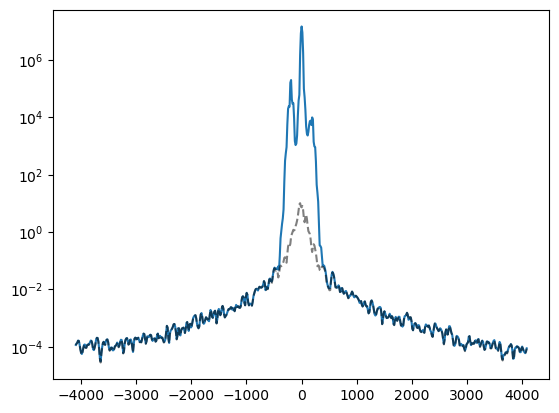

In [115]:
plt.plot(FT1.freqs, vd_spec[(0, 4)].abs().mean(0));
plt.plot(FT1.freqs, ve_spec[(0, 4)].abs().mean(0), c='k', ls='--', alpha=.5);
plt.yscale('log')

# Take incoherent average over remaining time bins

Now that the data are real-valued and don't have phase, we can still average the last few time bins, but this is now considered "incoherent", and as a consquence doesn't require rephasing.

In [116]:
vd_spec_tavg = vd_spec.time_average(inplace=False)
ve_spec_tavg = ve_spec.time_average(inplace=False)

print(f"remaining Ntimes = {vd_spec_tavg.Ntimes}")

remaining Ntimes = 1


# Take an incoherent average over baselines with the same length |b|

The delay power spectrum in fourier wave-vector k space is (k_x, k_y, k_z) = (b_x, b_y, tau), where b is the baseline vector and tau is the delay.

Thus, we can estimate a cylindrical 2D power spectrum as (k_perp, k_para) by averaging over the b_x and b_y dimensions in annuli. The mapping from (|b|, tau) -> (k_perp, k_para) is then analytic, given by equations 5 and 6 in https://arxiv.org/abs/1603.08958.

In [117]:
# get new redundant set averaging b_x and b_y in annuli
red_info = ba.telescope_model.build_reds(vd_spec_tavg.antpos, bls=vd_spec_tavg.bls, norm_vec=True, redtol=.1)
inc_reds = red_info[0]
inc_red_lens = np.array(red_info[4])

# average the data
vd_spec_avg = vd_spec_tavg.bl_average(reds=inc_reds, inplace=False)
ve_spec_avg = ve_spec_tavg.bl_average(reds=inc_reds, inplace=False)

In [118]:
# get k_perp and k_para mappings
kperps = inc_red_lens*cosmo.bl_to_kperp(avg_redshift)
kparas = FT1.freqs*cosmo.tau_to_kpara(avg_redshift)/1e9

# Now plot the 2D power spectrum

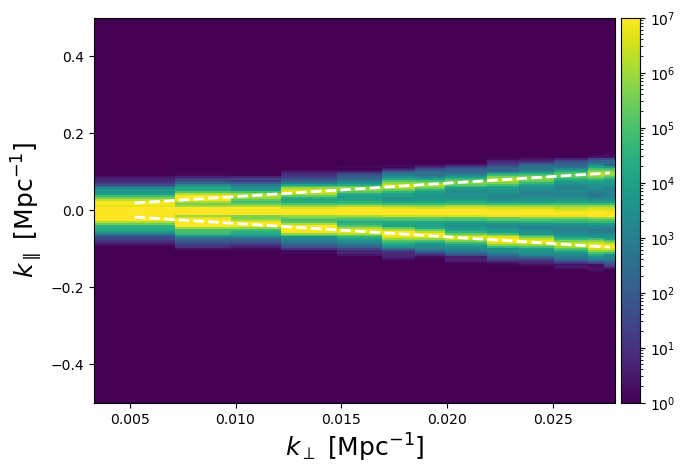

In [119]:
fig, ax = plt.subplots(figsize=(8, 5))
X, Y = np.meshgrid(kperps, kparas, indexing='ij')
cax = ax.pcolormesh(X, Y, vd_spec_avg.data.squeeze(), norm=LogNorm(vmin=1e0, vmax=1e7))
ax.set_xlabel(r'$k_\perp\ [{\rm Mpc}^{-1}]$', fontsize=18)
ax.set_ylabel(r'$k_\parallel\ [{\rm Mpc}^{-1}]$', fontsize=18)
# draw horizon wedge in white dashed lines
ax.plot(kperps, inc_red_lens / 2.99e8 * cosmo.tau_to_kpara(avg_redshift), lw=2, c='w', ls='--')
ax.plot(kperps, -inc_red_lens / 2.99e8 * cosmo.tau_to_kpara(avg_redshift), lw=2, c='w', ls='--')
ax.set_ylim(-.5, .5)
cbar = fig.colorbar(cax, pad=0.01); #cbar.set_label('P(k)', fontsize=14)

# Now compute 1D power spectrum

For short baselines we can basically just take the average across k_perp. If we have long baselines (> 100 m) then we need to do the spherical averaging more properly. Formally, the limit is k_perp << kpara.

In [120]:
# take a straight average across k_perp (only works for short baselines < 100m)
vd_pspec_1d = vd_spec_avg.data.squeeze().mean(0)
ve_pspec_1d = ve_spec_avg.data.squeeze().mean(0)

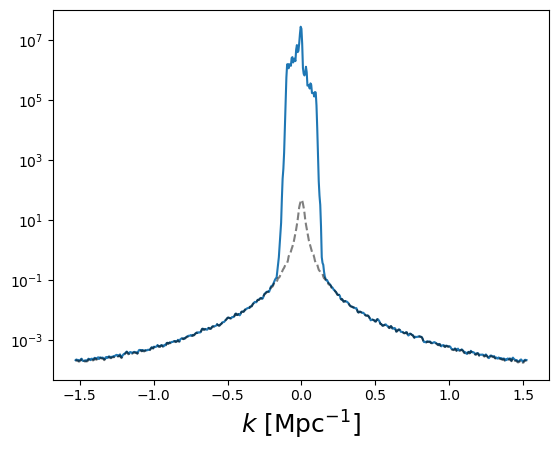

In [121]:
plt.plot(kparas, vd_pspec_1d)
plt.plot(kparas, ve_pspec_1d, c='k', ls='--', alpha=.5)
plt.yscale('log')
plt.xlabel(r'$k\ [{\rm Mpc}^{-1}]$', fontsize=18);